In [74]:
import numpy as np 
import pandas as pd 


In [75]:
df=pd.read_csv('C:\\Learn\\deep-learning-lab\\dataset\\Churn_Modelling.csv')

In [76]:
df.shape

(10000, 14)

In [77]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [79]:
df.duplicated().sum()

0

In [80]:
df.Exited.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [81]:
df.Geography.value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [82]:
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace=True)


In [83]:
df.shape

(10000, 11)

In [84]:

df.corr(numeric_only=True)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


In [85]:
df=pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True,dtype=int)


In [86]:
df.shape

(10000, 12)

In [87]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=["Exited"]),df.Exited,test_size=0.2,random_state=42)

In [88]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((8000, 11), (2000, 11), (8000,), (2000,))

In [89]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)


In [90]:
x_train_scaled

array([[ 0.35649971, -0.6557859 ,  0.34567966, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.20389777,  0.29493847, -0.3483691 , ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.96147213, -1.41636539, -0.69539349, ..., -0.57946723,
         1.73494238,  0.91324755],
       ...,
       [ 0.86500853, -0.08535128, -1.38944225, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.15932282,  0.3900109 ,  1.03972843, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [ 0.47065475,  1.15059039, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [91]:
x_test_scaled

array([[-0.57749609, -0.6557859 , -0.69539349, ...,  1.72572313,
        -0.57638802,  0.91324755],
       [-0.29729735,  0.3900109 , -1.38944225, ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.52560743,  0.48508334, -0.3483691 , ..., -0.57946723,
         1.73494238, -1.09499335],
       ...,
       [ 0.81311987,  0.77030065,  0.69270405, ..., -0.57946723,
        -0.57638802, -1.09499335],
       [ 0.41876609, -0.94100321, -0.3483691 , ..., -0.57946723,
        -0.57638802,  0.91324755],
       [-0.24540869,  0.00972116, -1.38944225, ...,  1.72572313,
        -0.57638802,  0.91324755]])

In [92]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [93]:
model=Sequential()
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

c:\Users\PIYUSH\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [94]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [96]:
history = model.fit(x_train_scaled,y_train,validation_data=(x_test_scaled,y_test),epochs=50,batch_size=32)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7046 - loss: 0.6013 - val_accuracy: 0.8035 - val_loss: 0.4961
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7951 - loss: 0.4805 - val_accuracy: 0.8085 - val_loss: 0.4443
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8027 - loss: 0.4416 - val_accuracy: 0.8175 - val_loss: 0.4134
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8152 - loss: 0.4181 - val_accuracy: 0.8260 - val_loss: 0.3980
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8296 - loss: 0.3990 - val_accuracy: 0.8340 - val_loss: 0.3790
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8414 - loss: 0.3806 - val_accuracy: 0.8425 - val_loss: 0.3662
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8486 - loss: 0.3674 - val_accuracy: 0.8440 - val_loss: 0.3589
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8506 - loss: 0.3584 - val_accuracy: 0.

In [97]:
model.layers[1].get_weights()

[array([[-4.4894597e-01,  7.2038043e-01,  2.7460000e-02,  1.0348660e+00,
          6.9807720e-01,  2.5639099e-01,  3.8597164e-01, -3.1425560e-01,
         -4.8600358e-01, -2.2473052e-01, -5.3777665e-01],
        [-2.5151068e-01,  1.5785214e-01,  1.1097840e-01,  4.6560347e-02,
         -6.5222899e-03, -6.6088125e-02, -7.3519820e-01,  3.5440701e-01,
          6.9252685e-02,  4.2322889e-01, -6.5929323e-01],
        [ 8.0005527e-02, -9.8120563e-02, -4.0347928e-01, -2.2809575e-01,
         -1.5483500e-03, -2.8862444e-01, -1.6923061e-01, -1.5933136e-04,
          4.6917027e-01,  1.5529804e-01,  5.8145094e-01],
        [-1.1986502e-01, -1.0462484e-01,  4.6368933e-01,  5.9996516e-01,
         -1.2814381e-02,  3.2382548e-01, -8.2970959e-01,  1.5617125e-01,
          3.2600597e-01, -1.4819431e-01,  5.4221157e-02],
        [-6.0500079e-01, -3.8453647e-01, -3.4212366e-01,  1.7665124e-01,
          4.0203571e-01,  4.7319151e-02, -4.8802622e-02, -1.4486811e+00,
         -2.6678255e-01,  7.8079557e-0

In [98]:
model.layers[0].get_weights()

[array([[ 3.8019605e-02,  4.8525184e-01,  1.5233753e-02, -3.1606138e-01,
         -3.3756348e-01,  2.3102863e-01,  6.3751645e-02,  1.6224902e-02,
          4.9198836e-02, -2.3787405e-01, -3.3441645e-03],
        [-7.7801341e-01,  5.2230746e-01,  2.9441628e-01,  1.4240450e-01,
          3.1243899e-01, -1.8609133e-01,  5.2050400e-01,  2.6873395e-01,
          7.8819585e-01, -7.0842129e-01, -1.7424566e-01],
        [-8.0869429e-02,  5.1750231e-01, -1.0612580e-01,  3.3868939e-01,
         -2.3190986e-01,  6.4513110e-02,  1.0595344e-03,  1.7332114e-01,
         -3.3040591e-02, -2.6704720e-01,  9.2067674e-02],
        [ 1.4418021e-01,  4.2954871e-01, -1.9570051e-01, -1.9209045e-01,
          5.2912360e-01,  7.2483741e-02, -5.1146740e-01, -1.5191433e-01,
          3.5473320e-01,  1.0080005e-02,  2.0724325e-02],
        [ 7.4684672e-02, -3.7430212e-01, -1.1295136e+00,  9.3440965e-02,
          7.2859192e-01, -3.2958558e-01, -5.8559529e-02,  9.5178798e-02,
          1.0477091e+00,  2.7126238e-0

In [99]:
weights,biases=model.layers[1].get_weights()

# print(weights)
print(biases)

[-0.02132528  0.33437726  0.29582664  0.2742212   0.20651573  0.43800256
 -0.5031353   0.2881196   0.4008711  -0.23684463 -0.15981694]


In [100]:
y_log=model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [101]:
y_pred=np.where(y_log>0.5,1,0)


In [102]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)*100

86.1

In [103]:
import matplotlib.pyplot as plt


In [104]:
history.history

{'accuracy': [0.7046250104904175,
  0.7951250076293945,
  0.8027499914169312,
  0.8152499794960022,
  0.8296250104904175,
  0.8413749933242798,
  0.8486250042915344,
  0.8506249785423279,
  0.8547499775886536,
  0.8566250205039978,
  0.856374979019165,
  0.8579999804496765,
  0.8598750233650208,
  0.8610000014305115,
  0.859250009059906,
  0.859375,
  0.8612499833106995,
  0.8613749742507935,
  0.8617500066757202,
  0.862625002861023,
  0.8615000247955322,
  0.8617500066757202,
  0.862500011920929,
  0.8621249794960022,
  0.8631250262260437,
  0.8622499704360962,
  0.8628749847412109,
  0.8640000224113464,
  0.8622499704360962,
  0.8637499809265137,
  0.862375020980835,
  0.8618749976158142,
  0.8643749952316284,
  0.862625002861023,
  0.862375020980835,
  0.8632500171661377,
  0.8642500042915344,
  0.8646249771118164,
  0.8627499938011169,
  0.8633750081062317,
  0.8654999732971191,
  0.8642500042915344,
  0.8652499914169312,
  0.8641250133514404,
  0.8665000200271606,
  0.86449998617

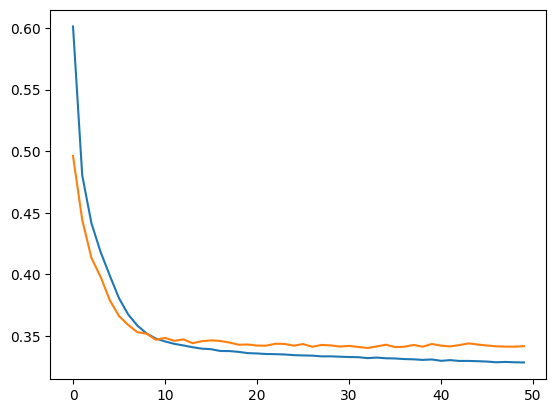

In [109]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])


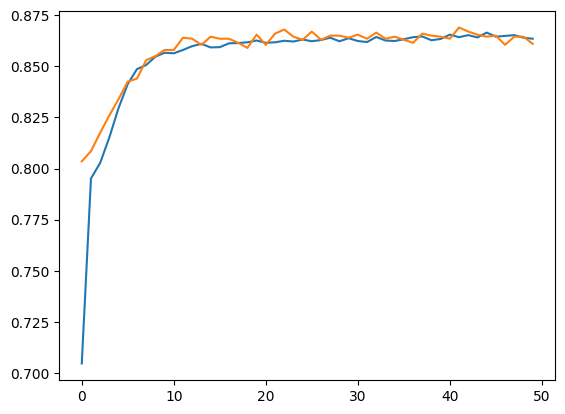

In [110]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

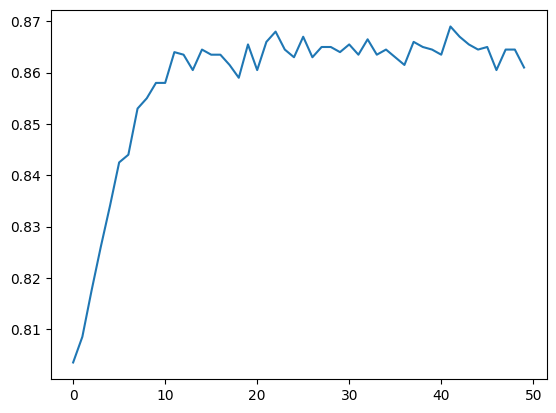

In [107]:
plt.plot(history.history['val_accuracy'])

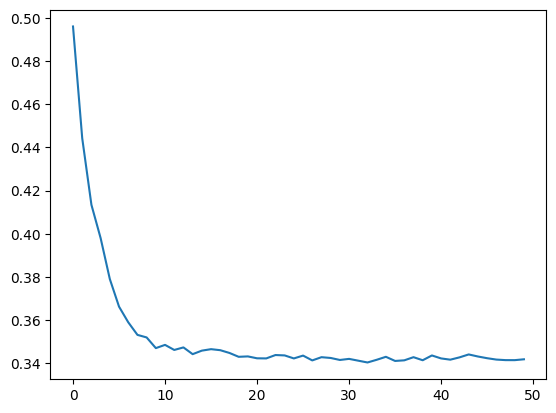

In [108]:
plt.plot(history.history['val_loss'])
